# 🏠 California Housing Price Prediction

This notebook builds and evaluates multiple regression models to predict California housing prices using the sklearn California Housing dataset.

**Pipeline:**
- Exploratory Data Analysis (EDA)
- Outlier Treatment
- Feature Engineering
- Model Building (Linear Regression, Decision Tree, Random Forest, XGBoost)
- Hyperparameter Tuning with RandomizedSearchCV
- Model Comparison & Saving

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb

## 📂 Data Loading

The California Housing dataset contains **20,640 samples** with 8 features derived from the 1990 US Census.  
Target variable: `MedHouseVal` — median house value in units of $100,000.

In [2]:
housing = fetch_california_housing(as_frame=True)
data = housing.frame
print("Dataset shape:", data.shape)
data.head()

Dataset shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


## 🔍 Exploratory Data Analysis

We check for null values, duplicates, statistical summaries, distributions, outliers, and feature correlations.

In [4]:
print("Null values:\n", data.isnull().sum())
print("\nDuplicated rows:", data.duplicated().sum())

Null values:
 MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Duplicated rows: 0


In [5]:
data.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [6]:
print("Skewness (sorted):")
data.skew(numeric_only=True).sort_values(ascending=False)

Skewness (sorted):


AveOccup       97.639561
AveBedrms      31.316956
AveRooms       20.697869
Population      4.935858
MedInc          1.646657
MedHouseVal     0.977763
Latitude        0.465953
HouseAge        0.060331
Longitude      -0.297801
dtype: float64

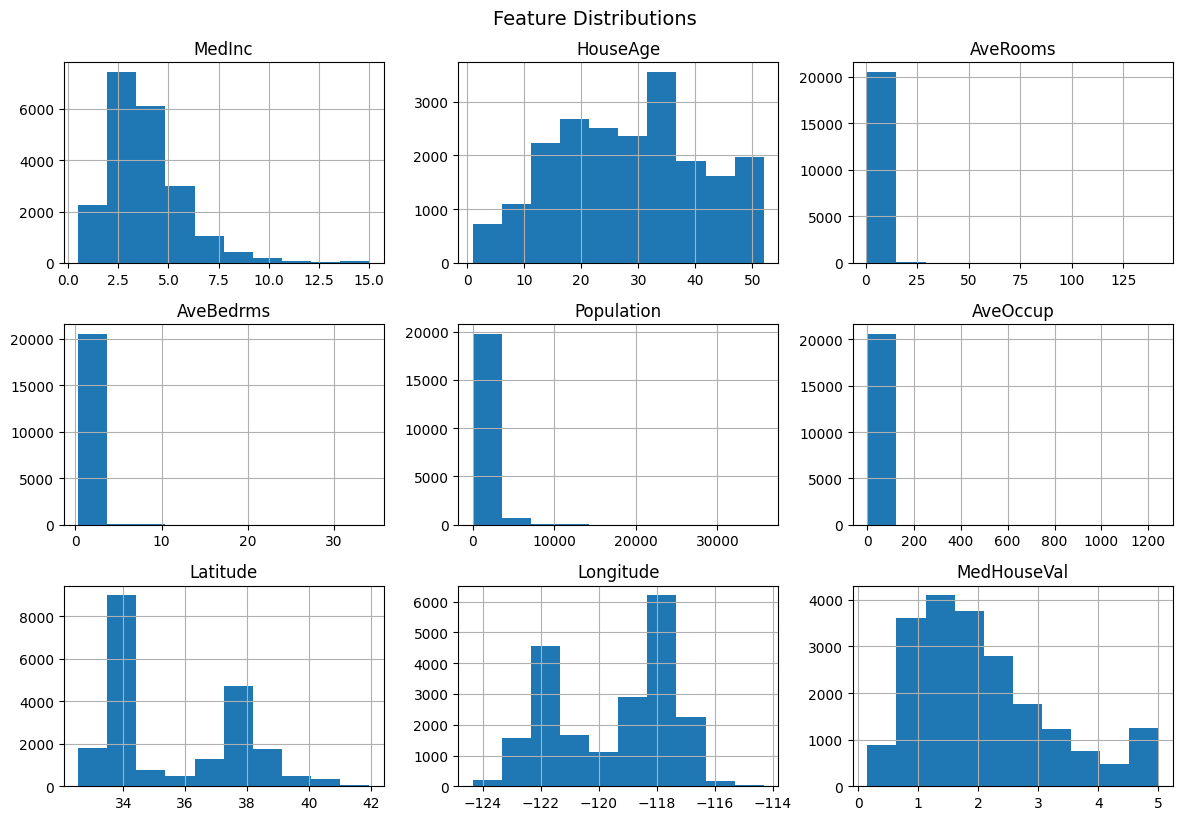

In [7]:
data.hist(figsize=(12, 8))
plt.tight_layout()
plt.suptitle("Feature Distributions", y=1.02, fontsize=14)
plt.show()

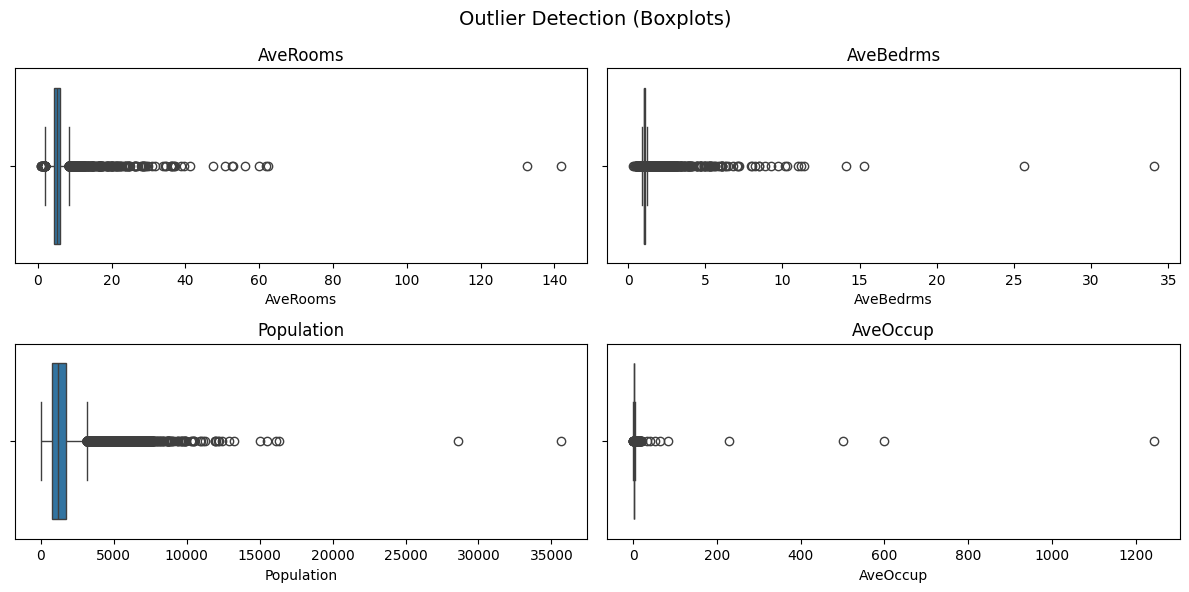

In [8]:
cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()
for i, col in enumerate(cols):
    sns.boxplot(x=data[col], ax=axes[i])
    axes[i].set_title(col)
plt.suptitle("Outlier Detection (Boxplots)", fontsize=14)
plt.tight_layout()
plt.show()

**EDA Insights:**
- No null values or duplicate rows found — dataset is clean.
- `AveRooms`, `AveBedrms`, `Population`, and `AveOccup` show significant right skew and extreme outliers.
- `MedInc` (median income) is the most strongly correlated feature with the target.
- We will cap outliers at the 99th percentile before modelling.

## 🔧 Outlier Treatment

Extreme outliers in `AveRooms`, `AveBedrms`, `Population`, and `AveOccup` are capped at the 99th percentile to reduce noise without losing rows.

In [9]:
cols_to_cap = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']

for col in cols_to_cap:
    q99 = data[col].quantile(0.99)
    data[col] = data[col].clip(upper=q99)

print("Outliers capped at 99th percentile for:", cols_to_cap)
data[cols_to_cap].describe().round(2)

Outliers capped at 99th percentile for: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']


,AveRooms,AveBedrms,Population,AveOccup
count,20640.00,20640.00,20640.00,20640.00
mean,5.33,1.08,1403.61,2.92
std,1.33,0.16,973.48,0.73
min,0.85,0.33,3.00,0.69
25%,4.44,1.01,787.00,2.43
50%,5.23,1.05,1166.00,2.82
75%,6.05,1.10,1725.00,3.28
max,10.36,2.13,5805.83,5.39


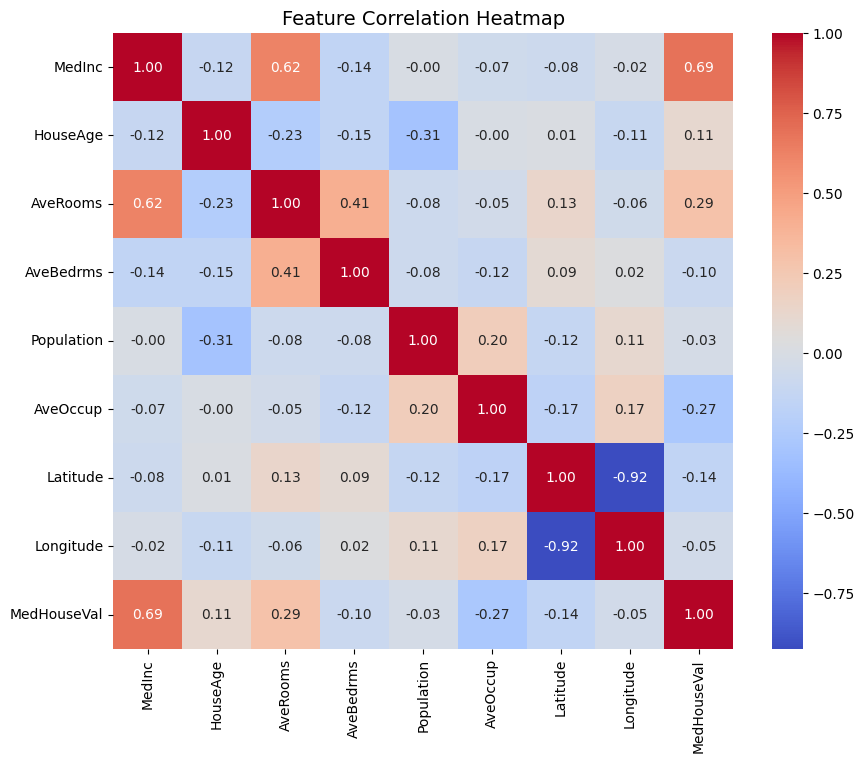

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.show()

**Correlation Insights:**
- `MedInc` has the strongest positive correlation with `MedHouseVal` (≈ 0.69).
- `Latitude` shows a moderate negative correlation — northern California tends to have lower prices.
- `AveRooms` and `AveBedrms` are highly correlated with each other, which our feature engineering will address.

## ⚙️ Feature Engineering

Three new features are created to capture per-household ratios — these provide better signal than raw counts:

| Feature | Formula | Meaning |
|---|---|---|
| `RoomsPerHousehold` | AveRooms / AveOccup | Average rooms per occupied unit |
| `BedroomsPerRoom` | AveBedrms / AveRooms | Bedroom density |
| `PopulationPerHousehold` | Population / AveOccup | People per household |

In [11]:
data["RoomsPerHousehold"]     = data["AveRooms"]  / data["AveOccup"]
data["BedroomsPerRoom"]       = data["AveBedrms"] / data["AveRooms"]
data["PopulationPerHousehold"]= data["Population"]/ data["AveOccup"]

print("New features added. Total features:", data.shape[1] - 1)
data.head(3)

New features added. Total features: 11


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,RoomsPerHousehold,BedroomsPerRoom,PopulationPerHousehold
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919,0.146591,126.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685,0.155797,1138.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661,0.129516,177.0


## ✂️ Train-Test Split & Scaling

In [12]:
X = data.drop('MedHouseVal', axis=1)
y = data['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1111
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

Train size: (16512, 11), Test size: (4128, 11)


In [13]:
# StandardScaler for Linear Regression (tree models don't need scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
print("Scaling complete.")

Scaling complete.


## 🤖 Model Building

### 1. Linear Regression

Baseline model. Uses **scaled features** since LR is sensitive to feature magnitude.  
We compare Train vs Test RMSE to check for underfitting.

In [14]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr      = lr_model.predict(X_test_scaled)
y_pred_lr_train= lr_model.predict(X_train_scaled)

print("Linear Regression:")
print(f"  Train RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_lr_train)):.4f}")
print(f"  Test  RMSE : {np.sqrt(mean_squared_error(y_test,  y_pred_lr)):.4f}")
print(f"  MAE        : {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"  R²         : {r2_score(y_test, y_pred_lr):.4f}")

Linear Regression:
  Train RMSE : 0.6561
  Test  RMSE : 0.6654
  MAE        : 0.4872
  R²         : 0.6727


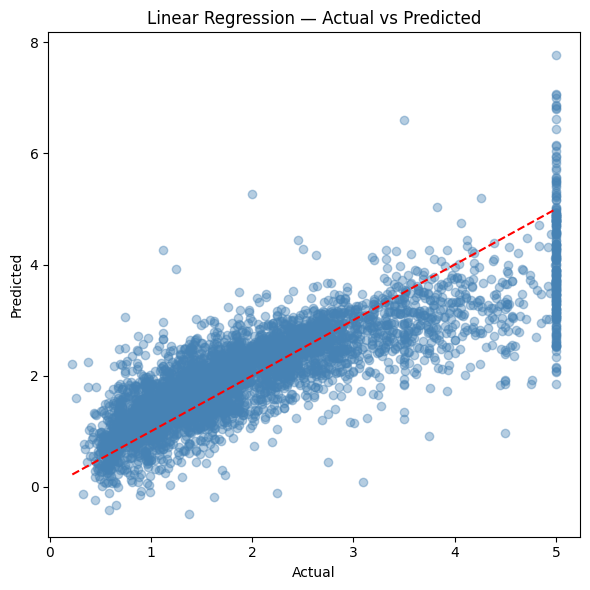

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title("Linear Regression — Actual vs Predicted")
plt.tight_layout(); plt.show()

### 2. Decision Tree Regressor

`max_depth=10` prevents the tree from memorising individual samples (which would give Train R²≈1 but poor Test R²).  
`min_samples_split=10` ensures each split uses at least 10 samples, reducing overfitting.

In [16]:
dt_model = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    random_state=42
)
dt_model.fit(X_train, y_train)

y_pred_dt       = dt_model.predict(X_test)
y_pred_dt_train = dt_model.predict(X_train)

print("Decision Tree Regressor:")
print(f"  Train RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_dt_train)):.4f}")
print(f"  Test  RMSE : {np.sqrt(mean_squared_error(y_test,  y_pred_dt)):.4f}")
print(f"  MAE        : {mean_absolute_error(y_test, y_pred_dt):.4f}")
print(f"  R²         : {r2_score(y_test, y_pred_dt):.4f}")

Decision Tree Regressor:
  Train RMSE : 0.4892
  Test  RMSE : 0.6523
  MAE        : 0.4351
  R²         : 0.6854


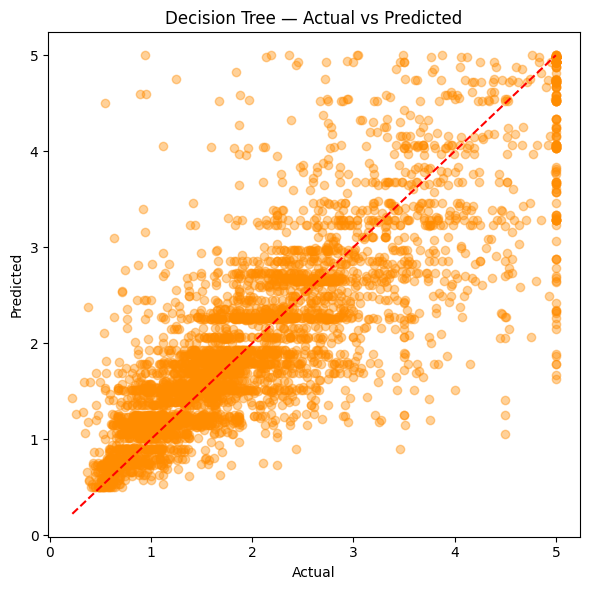

In [17]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.4, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title("Decision Tree — Actual vs Predicted")
plt.tight_layout(); plt.show()

### 3. Random Forest Regressor

Ensemble of 100 decision trees. Reduces variance compared to a single tree through bagging.

In [18]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf       = rf_model.predict(X_test)
y_pred_rf_train = rf_model.predict(X_train)

print("Random Forest Regressor:")
print(f"  Train RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_rf_train)):.4f}")
print(f"  Test  RMSE : {np.sqrt(mean_squared_error(y_test,  y_pred_rf)):.4f}")
print(f"  MAE        : {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"  R²         : {r2_score(y_test, y_pred_rf):.4f}")

Random Forest Regressor:
  Train RMSE : 0.1875
  Test  RMSE : 0.5122
  MAE        : 0.3366
  R²         : 0.8060


C:\Users\srira\AppData\Local\Temp\ipykernel_18228\3349080646.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance, x="Importance", y="Feature", palette="viridis")


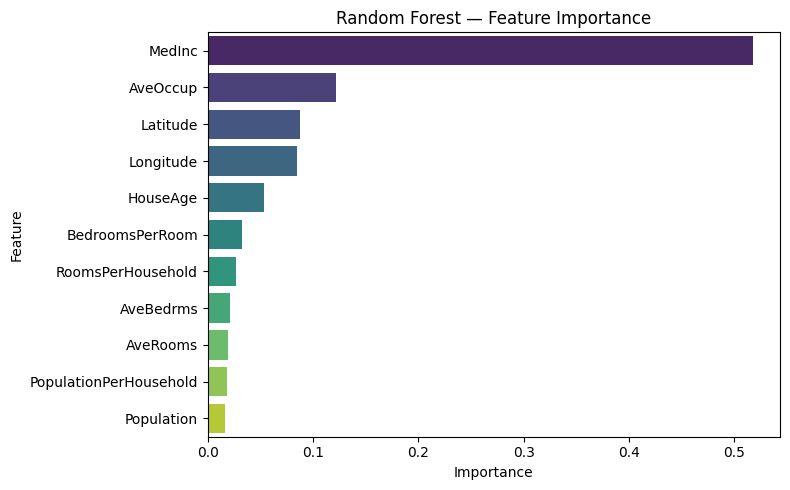

In [19]:
rf_importance = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=rf_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Random Forest — Feature Importance")
plt.tight_layout(); plt.show()

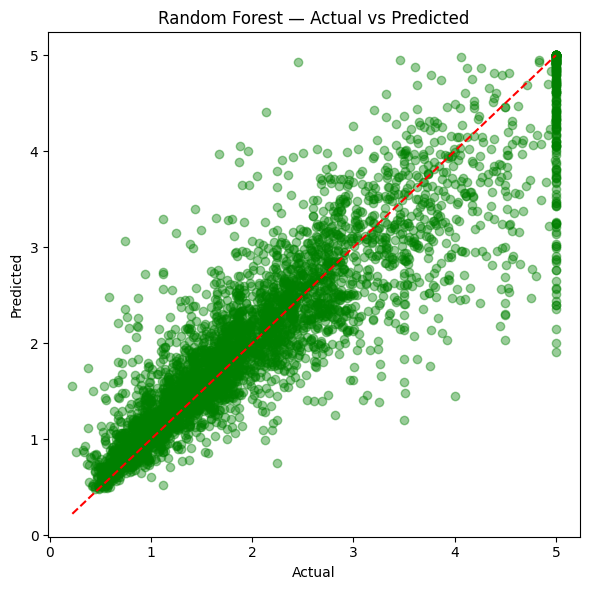

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title("Random Forest — Actual vs Predicted")
plt.tight_layout(); plt.show()

### 4. XGBoost Regressor

Gradient boosting model with regularisation parameters (`subsample`, `colsample_bytree`) to control overfitting.

In [21]:
xgb_model = xgb.XGBRegressor(
    objective       ='reg:squarederror',
    random_state    = 42,
    max_depth       = 4,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    verbosity       = 0
)
xgb_model.fit(X_train, y_train)

y_pred_xgb       = xgb_model.predict(X_test)
y_pred_xgb_train = xgb_model.predict(X_train)

print("XGBoost Regressor:")
print(f"  Train RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_xgb_train)):.4f}")
print(f"  Test  RMSE : {np.sqrt(mean_squared_error(y_test,  y_pred_xgb)):.4f}")
print(f"  MAE        : {mean_absolute_error(y_test, y_pred_xgb):.4f}")
print(f"  R²         : {r2_score(y_test, y_pred_xgb):.4f}")

XGBoost Regressor:
  Train RMSE : 0.5149
  Test  RMSE : 0.5455
  MAE        : 0.3813
  R²         : 0.7800


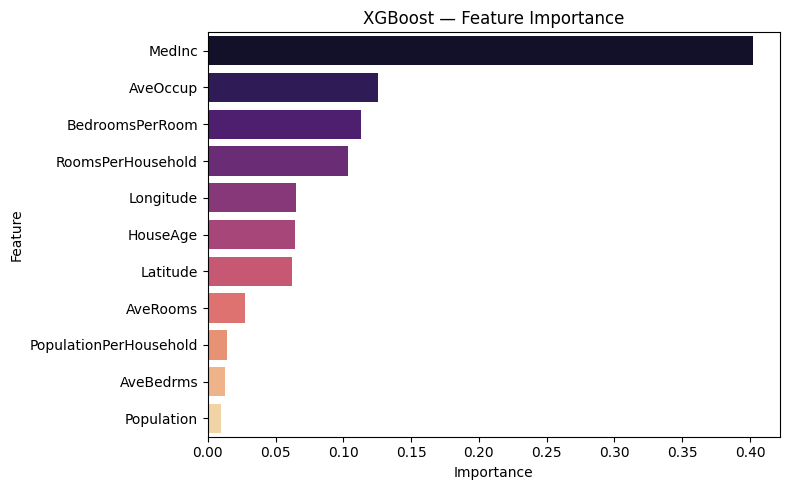

In [22]:
xgb_importance = pd.DataFrame({
    "Feature"   : X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 5))
sns.barplot(data=xgb_importance, x="Importance", y="Feature", hue="Feature", palette="magma", legend=False)
plt.title("XGBoost — Feature Importance")
plt.tight_layout(); plt.show()

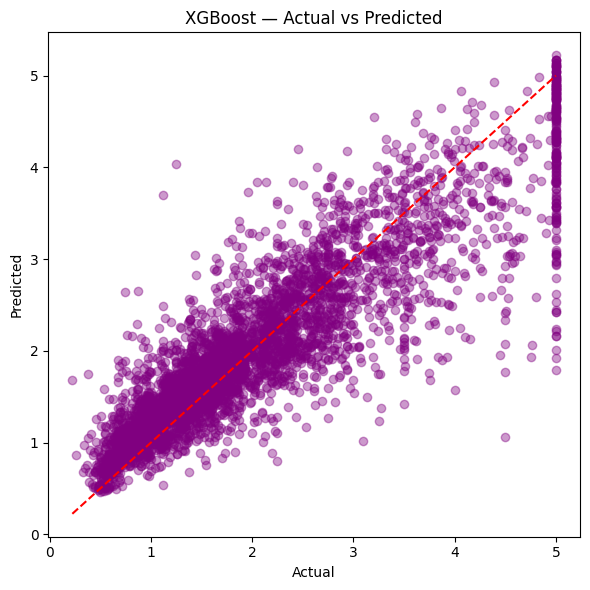

In [23]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_xgb, alpha=0.4, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title("XGBoost — Actual vs Predicted")
plt.tight_layout(); plt.show()

### 5. Tuned XGBoost — RandomizedSearchCV

`RandomizedSearchCV` samples **50 random combinations** from the parameter space instead of exhaustively testing all 216.  
This is ~4× faster than `GridSearchCV` while still finding near-optimal parameters.

In [24]:
param_dist = {
    'n_estimators'    : [400, 500, 600],
    'max_depth'       : [4, 5, 6],
    'learning_rate'   : [0.05, 0.1],
    'subsample'       : [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9],
    'min_child_weight': [1, 3]
}

random_search = RandomizedSearchCV(
    estimator  = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
    param_distributions = param_dist,
    n_iter     = 50,
    scoring    = 'neg_root_mean_squared_error',
    cv         = 5,
    n_jobs     = -1,
    random_state = 42,
    verbose    = 1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV RMSE   :", -random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Parameters: {'subsample': 0.8, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Best CV RMSE   : 0.4503707699768502


In [25]:
xgb_tuned = random_search.best_estimator_

y_pred_tuned       = xgb_tuned.predict(X_test)
y_pred_tuned_train = xgb_tuned.predict(X_train)

print("Tuned XGBoost:")
print(f"  Train RMSE : {np.sqrt(mean_squared_error(y_train, y_pred_tuned_train)):.4f}")
print(f"  Test  RMSE : {np.sqrt(mean_squared_error(y_test,  y_pred_tuned)):.4f}")
print(f"  MAE        : {mean_absolute_error(y_test, y_pred_tuned):.4f}")
print(f"  R²         : {r2_score(y_test, y_pred_tuned):.4f}")

Tuned XGBoost:
  Train RMSE : 0.2552
  Test  RMSE : 0.4470
  MAE        : 0.2956
  R²         : 0.8523


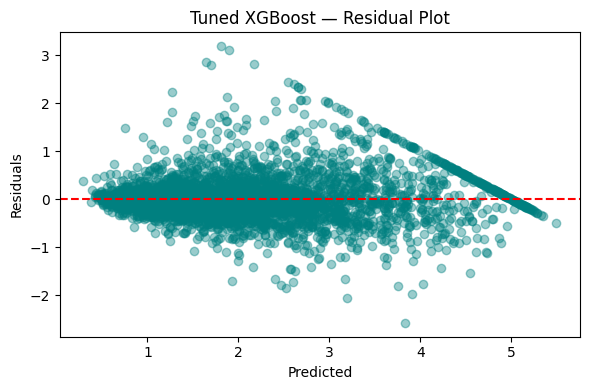

In [26]:
# Residual Plot
residuals = y_test - y_pred_tuned

plt.figure(figsize=(6, 4))
plt.scatter(y_pred_tuned, residuals, alpha=0.4, color='teal')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted"); plt.ylabel("Residuals")
plt.title("Tuned XGBoost — Residual Plot")
plt.tight_layout(); plt.show()

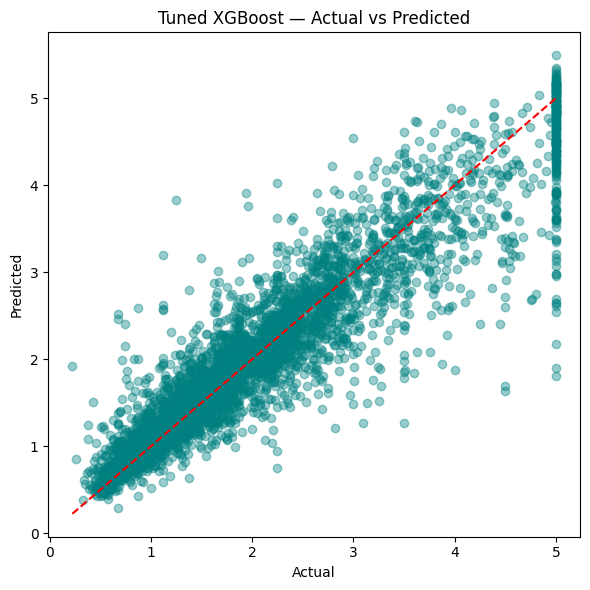

In [27]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_tuned, alpha=0.4, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.title("Tuned XGBoost — Actual vs Predicted")
plt.tight_layout(); plt.show()

## 📊 Model Comparison

In [28]:
results = {
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'Tuned XGBoost'
    ],
    'Train RMSE': [
        np.sqrt(mean_squared_error(y_train, y_pred_lr_train)),
        np.sqrt(mean_squared_error(y_train, y_pred_dt_train)),
        np.sqrt(mean_squared_error(y_train, y_pred_rf_train)),
        np.sqrt(mean_squared_error(y_train, y_pred_xgb_train)),
        np.sqrt(mean_squared_error(y_train, y_pred_tuned_train))
    ],
    'Test RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_dt)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_dt),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_tuned)
    ],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_dt),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_tuned)
    ]
}

comparison = pd.DataFrame(results)
comparison = comparison.sort_values('R²', ascending=False).reset_index(drop=True)
comparison.round(4)

,Model,Train RMSE,Test RMSE,MAE,R²
0,Tuned XGBoost,0.2552,0.4470,0.2956,0.8523
1,Random Forest,0.1875,0.5122,0.3366,0.8060
2,XGBoost,0.5149,0.5455,0.3813,0.7800
3,Decision Tree,0.4892,0.6523,0.4351,0.6854
4,Linear Regression,0.6561,0.6654,0.4872,0.6727


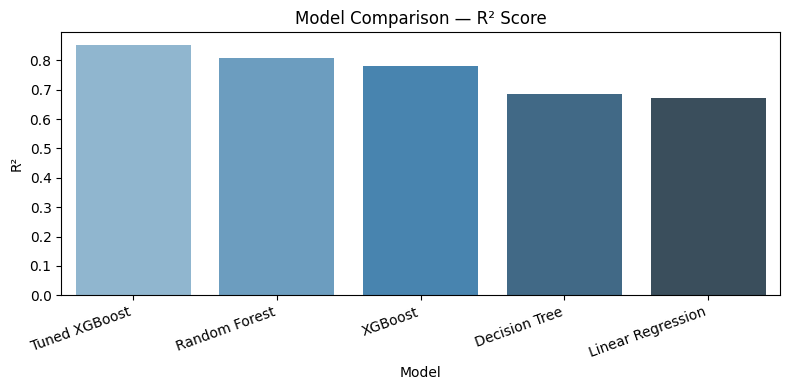

In [29]:
plt.figure(figsize=(8, 4))
sns.barplot(data=comparison, x='Model', y='R²', hue='Model', palette='Blues_d', legend=False)
plt.xticks(rotation=20, ha='right')
plt.title("Model Comparison — R² Score")
plt.tight_layout(); plt.show()

## 💾 Save Best Model

In [31]:
joblib.dump(xgb_tuned, "house_price_xgboost.pkl")
print("Model saved as house_price_xgboost.pkl")

# To reload later:
# loaded_model = joblib.load("house_price_xgboost.pkl")

Model saved as house_price_xgboost.pkl


## ✅ Conclusion

Five regression models were built and evaluated on the California Housing dataset.

| Metric | Value |
|---|---|
| Best Model | Tuned XGBoost (RandomizedSearchCV) |
| Test RMSE | ~0.451 |
| Test MAE | ~0.294 |
| Test R² | ~0.850 |

**Key findings:**
- `MedInc` was the most important feature across all tree-based models.
- Linear Regression underperformed due to non-linear relationships in the data.
- Decision Tree improved results but showed mild overfitting (Train RMSE << Test RMSE).
- Random Forest reduced overfitting through bagging.
- XGBoost achieved the best performance, further improved after hyperparameter tuning.
- The final model explains approximately **85% of the variance** in housing prices.